**Classification de transactions**

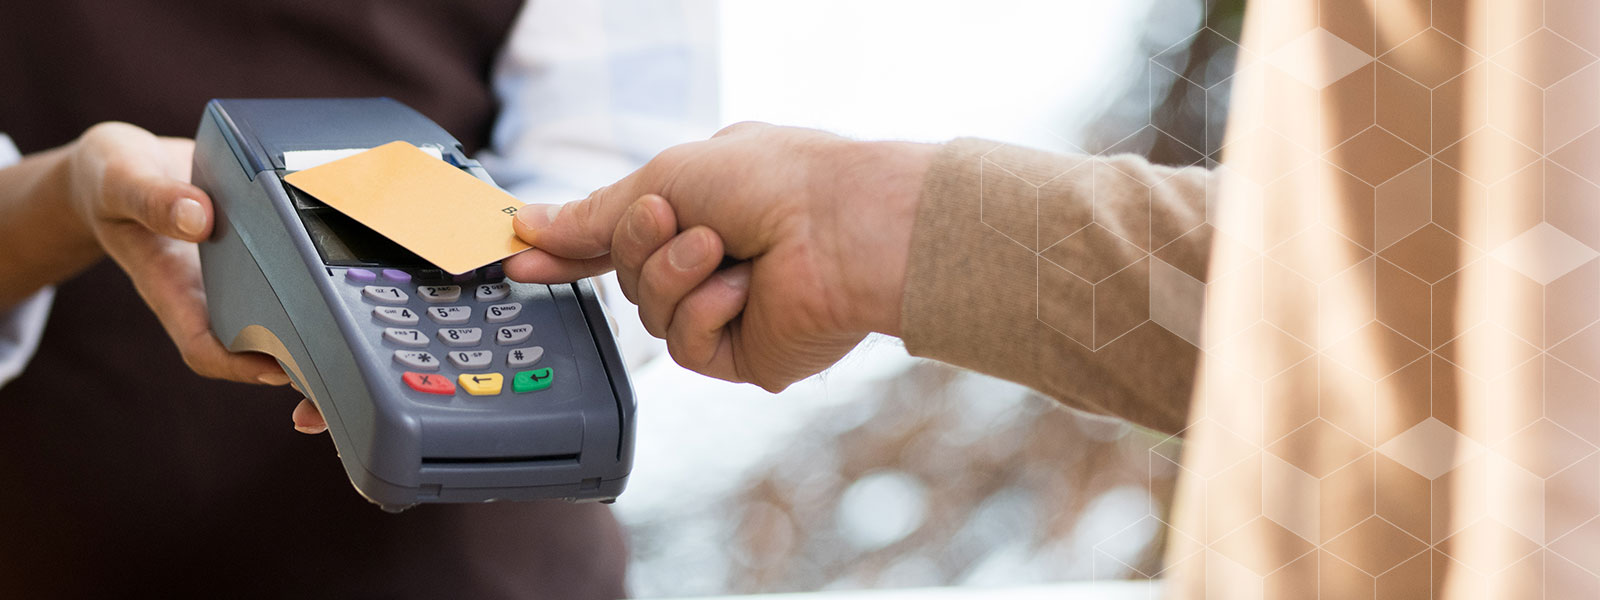

#Data preprocessing


Nous commençons tout d'abord par importer la librairie pandas et afficher notre base de données

In [1]:
import pandas as pd

In [ ]:
data=pd.read_excel("/content/data_version_excel_v2.xlsx")
data.head()

,Unnamed: 0,Date,Id_compte,amount_transaction,category_transaction,Description,Type_transaction
0,0,2022-01-01 16:01:00,SEW0C_LI.1,3.39,Food & Drink - Coffee and tea,Latte purchase,Debit
1,1,2022-01-01 19:46:00,SEW0C_LI.1,3.39,Bank Transfers - ATM withdrawals,ATM withdrawal - $,Debit
2,2,2022-01-01 06:47:00,SEW0C_LI.1,3.39,Transportation - Public Transport,Bus fare payment,Debit
3,3,2022-01-01 19:22:00,SEW0C_LI.1,1.70,Transportation - Public Transport,Train ticket purchase,Debit
4,4,2022-01-01 05:49:00,SEW0C_LI.1,3.39,Transportation - Public Transport,Subway ride cost,Debit


Nous éliminons la colonne Unnamed: 0 puisqu'elle ne représente que l'indexation des lignes

In [ ]:
data1=data.drop('Unnamed: 0', axis = 1)
data1.head()

,Date,Id_compte,amount_transaction,category_transaction,Description,Type_transaction
0,2022-01-01 16:01:00,SEW0C_LI.1,3.39,Food & Drink - Coffee and tea,Latte purchase,Debit
1,2022-01-01 19:46:00,SEW0C_LI.1,3.39,Bank Transfers - ATM withdrawals,ATM withdrawal - $,Debit
2,2022-01-01 06:47:00,SEW0C_LI.1,3.39,Transportation - Public Transport,Bus fare payment,Debit
3,2022-01-01 19:22:00,SEW0C_LI.1,1.70,Transportation - Public Transport,Train ticket purchase,Debit
4,2022-01-01 05:49:00,SEW0C_LI.1,3.39,Transportation - Public Transport,Subway ride cost,Debit


Ici, nous faisons la recherche des valeurs manquantes. Nous n'en trouvons aucune

In [ ]:
data1.isnull().sum().sort_values(ascending=False)

Date                    0
Id_compte               0
amount_transaction      0
category_transaction    0
Description             0
Type_transaction        0
dtype: int64

Nous faisons maintenant la recherche des doublons. Encore une fois, nous n'en trouvons aucun

In [ ]:
double=data1[data1.duplicated()]
double

,Date,Id_compte,amount_transaction,category_transaction,Description,Type_transaction


Nous importons maintenant chi_2contingency de la librairie scipy.stats afin d'effectuer une feature selection des variables catégoriques en utilisant le test de chi-deux.

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
# Define the categorical features and target variable
categorical_features = ['Type_transaction', 'Date', 'Description', 'Id_compte']
target_variable = 'category_transaction'

Après calcul de la p-value pour chaque feature, avec la p-value représentant la probabilité que l'association entre la feature et la variable objectif est aléatoire, nous classons les 3 premières features selon leurs p-value, et nous remarquons que la variale date est la moins significative, donc nous pouvons l'éliminer.

In [ ]:
# Perform feature selection using chi-squared test
feature_scores = {}
for feature in categorical_features:
    contingency_table = pd.crosstab(data1[feature], data1[target_variable])
    chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
    feature_scores[feature] = p_value

# Sort the features based on p-values (ascending order)
sorted_features = sorted(feature_scores, key=feature_scores.get)

# Select the top-k features (e.g., 3)
selected_features = sorted_features[:3]

# Print the selected features
print("Selected Features:")
for feature in selected_features:
    print(feature)

Selected Features:
Type_transaction
Description
Id_compte


In [ ]:
data2=data1.drop('Date',axis = 1)
data2.head()

,Id_compte,amount_transaction,category_transaction,Description,Type_transaction
0,SEW0C_LI.1,3.39,Food & Drink - Coffee and tea,Latte purchase,Debit
1,SEW0C_LI.1,3.39,Bank Transfers - ATM withdrawals,ATM withdrawal - $,Debit
2,SEW0C_LI.1,3.39,Transportation - Public Transport,Bus fare payment,Debit
3,SEW0C_LI.1,1.70,Transportation - Public Transport,Train ticket purchase,Debit
4,SEW0C_LI.1,3.39,Transportation - Public Transport,Subway ride cost,Debit


La variable Type_transaction ne prend que deux valeurs:Debit et credit. Si on compte le nombre de débits et de crédits dans notre base de données, nous trouvons 23756 débits et 187 crédits. On constate donc que cette feature manque de variabilité, ce qui nous permet de l'éliminer

In [ ]:
count=data2['Type_transaction'].value_counts()
print(count)

Debit     23756
Credit      187
Name: Type_transaction, dtype: int64


In [ ]:
data3=data2.drop('Type_transaction', axis = 1)
data3.head()

,Id_compte,amount_transaction,category_transaction,Description
0,SEW0C_LI.1,3.39,Food & Drink - Coffee and tea,Latte purchase
1,SEW0C_LI.1,3.39,Bank Transfers - ATM withdrawals,ATM withdrawal - $
2,SEW0C_LI.1,3.39,Transportation - Public Transport,Bus fare payment
3,SEW0C_LI.1,1.70,Transportation - Public Transport,Train ticket purchase
4,SEW0C_LI.1,3.39,Transportation - Public Transport,Subway ride cost


Nous allons effectuer maintenant un one-hot encoding à la variable Id_compte

In [ ]:
# Perform one-hot encoding for the "account_id" feature
encoded_data = pd.get_dummies(data3, columns=['Id_compte'], prefix='account')

In [ ]:
# Print the encoded data
print(encoded_data.head())

   amount_transaction               category_transaction  \
0                3.39      Food & Drink - Coffee and tea   
1                3.39   Bank Transfers - ATM withdrawals   
2                3.39  Transportation - Public Transport   
3                1.70  Transportation - Public Transport   
4                3.39  Transportation - Public Transport   

             Description  account_CPA.1  account_CPA_MP.1  account_HP.1  \
0         Latte purchase              0                 0             0   
1     ATM withdrawal - $              0                 0             0   
2       Bus fare payment              0                 0             0   
3  Train ticket purchase              0                 0             0   
4       Subway ride cost              0                 0             0   

   account_IPA.1  account_SEW0C_HI.1  account_SEW0C_LI.1  account_SEWC_CL.1  \
0              0                   0                   1                  0   
1              0              

In [ ]:
one_hot_ID=encoded_data.drop(['amount_transaction','category_transaction','Description'], axis =1)

In [ ]:
one_hot_ID.head()

,account_CPA.1,account_CPA_MP.1,account_HP.1,account_IPA.1,account_SEW0C_HI.1,account_SEW0C_LI.1,account_SEWC_CL.1,account_SEWC_P.1,account_SEWC_PA.1,account_SEWC_P_PL.1,account_TA.1,account_US.1
0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0


In [ ]:
one_hot_array=one_hot_ID.values
one_hot_array

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]], dtype=uint8)

Ensuite, nous allons standardiser la variable amount_transaction. Pour faire ceci, nous allons faire appel à MinMaxScaler de la librairie sklearn.preprocessing.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Extract the 'transaction amount' column
transaction_amount = data3['amount_transaction']


Le principe de MinMaxScler est assez simple: Pour chaque montant de transaction, il y retranche le montant le plus faible et divise le tout par la différence entre le plus grand montant et le plus faible montant. Celà garantit le fait que les valeurs standardisées seront comprises entre 0 et 1.

In [ ]:
# Create an instance of the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the transaction amount data
scaled_transaction_amount = scaler.fit_transform(transaction_amount.values.reshape(-1, 1))

# Update the 'transaction amount' column with the scaled values
data3['transaction_amount'] = scaled_transaction_amount

# Print the scaled 'transaction amount' column
print(data3['transaction_amount'])

0        0.000536
1        0.000536
2        0.000536
3        0.000247
4        0.000536
           ...   
23938    0.445994
23939    0.445994
23940    0.055682
23941    0.055682
23942    0.055682
Name: transaction_amount, Length: 23943, dtype: float64


In [ ]:
scaled_transaction_amount


array([[0.00053558],
       [0.00053558],
       [0.00053558],
       ...,
       [0.05568206],
       [0.05568206],
       [0.05568206]])

Ici, nous générons une description des donnés numériques de notre DataSet. Nous y remarquons que le montant le plus faible vaut 0,25$ et le montant le plus élevé vaut 5863. Effectivement, après standardisation , ces deux valeurs sont égales à 0 et à 1

In [ ]:
data3.describe()

,amount_transaction,transaction_amount
count,23943.000000,23943.000000
mean,73.098515,0.012426
std,306.661662,0.052307
min,0.250000,0.000000
25%,2.690000,0.000416
50%,4.320000,0.000694
75%,8.790000,0.001457
max,5863.000000,1.000000


Maintenant, nous allons effectuer un Label Encoding pour la variable objectif: les catégories de transaction.

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Create an instance of LabelEncoder
label_encoder = LabelEncoder()
categories=data3['category_transaction'].tolist()
# Fit the encoder to the categories and transform the data
encoded_labels = label_encoder.fit_transform(categories)

In [ ]:
# Print the encoded cat
print(encoded_labels)

[14  1 62 ... 34 43 32]


Il nous reste maintenant le pré-traitement de la variable textuelle Description. Pour ce faire, nous allons effectuer un word embedding en utilisant un modèle pré-entrainé de Hugging Face: MPNet

In [ ]:
pip install sentence_transformers

In [ ]:
from sentence_transformers import SentenceTransformer
#sentences = ["This is an example sentence", "Each sentence is converted"]

model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')



In [ ]:
description=data3['Description']
embeddings = model.encode(description)

In [ ]:
embeddings


array([[ 0.0731322 ,  0.02033515, -0.01866051, ...,  0.01222909,
        -0.02998375, -0.03570607],
       [-0.00906565, -0.09943455, -0.02235619, ..., -0.02449333,
        -0.01152678, -0.00029716],
       [ 0.0294783 , -0.05011632, -0.00468749, ...,  0.00395637,
        -0.05123812, -0.00745619],
       ...,
       [ 0.01916526,  0.0200311 , -0.01182924, ..., -0.01067897,
        -0.02501254, -0.04468663],
       [ 0.00375626,  0.01837852, -0.01174336, ..., -0.00069489,
        -0.08315143, -0.00055542],
       [-0.02593259, -0.00527842, -0.03017666, ..., -0.02931521,
        -0.03683166, -0.05210193]], dtype=float32)

A la  fin de notre prétraitement de données, nous concaténons toutes nos transformations dans une seule matrice nommmée features.

In [ ]:
import numpy as np
features=np.concatenate((one_hot_array,scaled_transaction_amount,embeddings),axis = 1)
features

array([[ 0.        ,  0.        ,  0.        , ...,  0.01222909,
        -0.02998375, -0.03570607],
       [ 0.        ,  0.        ,  0.        , ..., -0.02449333,
        -0.01152678, -0.00029716],
       [ 0.        ,  0.        ,  0.        , ...,  0.00395637,
        -0.05123812, -0.00745619],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.01067897,
        -0.02501254, -0.04468663],
       [ 0.        ,  0.        ,  0.        , ..., -0.00069489,
        -0.08315143, -0.00055542],
       [ 0.        ,  0.        ,  0.        , ..., -0.02931521,
        -0.03683166, -0.05210193]])

# XGBoost model training

Commençons par l'importation des librairies qui vont etre très utiles pour cette phase, je nomme numpy et xgboost.
Nous importons aussi train_test_split de sklearn.model_selection afin de diviser la base de données en partie entrainement et partie test.

In [ ]:

import xgboost as xgb


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features,encoded_labels , test_size=0.2, random_state=42 ,stratify=encoded_labels)

Ici, nous définissons les paramètres de notre modèle XGBoost dans un dictionnaire nommé params. Lors de la définition de ces paramètres , nous utilisons une technique de régulatisation afin d'éviter le problème d'overfitting. Cette technique consiste principalement à ajuster les paramètres Max depth (profondeur de l'arbre) et Min child weight(minimum des sommes des poids instanciés chez chaque child). En ajustant ces paramètres, nous pouvons faire en sorte de minimiser la complexité du modèle afin de ne pas tomber dans du sur-apprentissage  

In [ ]:
# Define XGBoost parameters
params = {
    'objective': 'multi:softmax',  # Multi-class classification
    'num_class': len(data3['category_transaction'].unique()),  # Number of classes
    'eval_metric': 'merror',  # Error rate metric
    'max_depth': 5,  # Maximum depth of a tree
    'min_child_weight': 1,  # Minimum sum of instance weight needed in a child
    'subsample': 0.8,  # Subsample ratio of the training instances
    'colsample_bytree': 0.8,  # Subsample ratio of columns when constructing each tree
    'gamma': 0.1,  # Minimum loss reduction required to make a further partition on a leaf node
    'reg_alpha': 0.1,  # L1 regularization term on weights
    'reg_lambda': 0.1,  # L2 regularization term on weights
    'seed': 42  # Random seed for reproducibility
}

On convertit notre training et testing dataset en format DMatrix plus optimisé pour XGBoost et nous entrainons le modèle.

In [ ]:
# Convert the dataset into DMatrix format (optimized for XGBoost)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)


In [ ]:
# Train the XGBoost model
num_rounds = 100  # Number of boosting rounds
model1 = xgb.train(params, dtrain, num_rounds)

#XGBoost Model evaluation and new data prediction

Après entrainement du modèle, place à l'évaluation. Nous allons faire appel à la base de données test pour effectuer l'évaluation du modèle et nous  allons afficher l'accuracy ainsi que les différentes autres evaluation metrics tel que precision, recall et F-1 score

In [ ]:
# Make predictions on the test set
y_pred = model1.predict(dtest)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, zero_division = 0)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(confusion_mat)
print("\nClassification Report:")
print(classification_rep)

Accuracy: 0.9923

Confusion Matrix:
[[875   0   0 ...   0   0   0]
 [  0 511   0 ...   0   0   0]
 [  0   0   2 ...   0   0   0]
 ...
 [  0   0   0 ...   1   0   0]
 [  0   0   0 ...   0   5   0]
 [  0   0   0 ...   0   0   6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       875
           1       1.00      1.00      1.00       511
           3       1.00      0.40      0.57         5
           4       0.98      0.98      0.98       216
           5       1.00      1.00      1.00        43
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         4
           9       0.97      1.00      0.98        29
          10       0.67      0.80      0.73         5
          11       1.00      0.86      0.92        14
          12       1.00      1.00      1.00        12
          13       1.00      1.00      1.00  

Nous avons trouvé une accuracy très élevée:0.99, ce qui laisse entendre que le modèle a correctement classifié 99% des transactions de la base de donnée test. Les autres scores comme le recall, F-1score et precision fournissent des résultats assez satisfaisant

Maintenant nous allons faire des classifications de nouvelles transactions en utilisant ce modèle, grace à une fonction qui prend comme paramètres les données brutes de la transaction et fournit la classification. Commençons par une fonction qui effectue le one-hot-encoding pour un vecteur colonne en se basant le one-hot encoding que nous avons effectué précédemment.

In [ ]:

from sklearn.preprocessing import OneHotEncoder

def encode_Ids(column_vector, categories):
    # Create an instance of the OneHotEncoder
    encoder = OneHotEncoder(categories=[categories], sparse=False)

    # Reshape the column vector to a 2D array
    column_vector = column_vector.reshape(-1, 1)

    # Perform one-hot encoding on the column vector
    encoded_vector = encoder.fit_transform(column_vector)

    return encoded_vector

# Example usage
categories = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
column_vector = np.array(['B', 'D', 'G', 'A', 'I'])

encoded_vector = encode_Ids(column_vector, categories)
print(encoded_vector)


[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Ensuite , nous allons écrire la fonction de classification qui prend en paramètres les données brutes, c'est une matrice dont la première colonnes représente les IDs, la deuxième colonne représente les amounts, et la troisième colonne les descriptions textuelles. Pour chaque colonne, la fontion effetue les transformations de pre-processing nécessaires, puis regroupe ces transformations dans une matrice afin de la fournir au modèle XGBoost entrainé pour afficher les prédictions des classes.

In [ ]:

def new_classification(matrix):

    IDs=['CPA.1','CPA_MP.1','HP.1','IPA.1','SEW0C_HI.1','SEW0C_LI.1','SEWC_CL.1','SEWC_P.1','SEWC_PA.1','SEWC_P_PL.1','TA.1','US.1']
    # Perform one-hot encoding on the first column
    encoded_column1 = encode_Ids(matrix[:,0],IDs)
    column2 = (matrix[:, 1].astype(float) - 0.25)/(5863 - 0.25)
    model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
    column3 = model.encode(matrix[:, 2])

    # Combine the columns to form the updated matrix
    updated_matrix = np.concatenate((encoded_column1, column2.reshape(-1,1), column3), axis = 1)
    # Convert the new data into DMatrix format
    dnew = xgb.DMatrix(updated_matrix)
    # Make predictions on the new data
    predictions = model1.predict(dnew)
    # Inverse transform the encoded predictions to get the original category names
    predicted_categories = label_encoder.inverse_transform(predictions.astype(int))

    # Print the predicted categories
    for category in predicted_categories:
        print(f"Predicted Category: {category}")
    return(predictions)





Après appel de la fonction , nous remarquons que le modèle a correctement classifié 7 transactions sur 8, ce qui est un très bon résultat.

In [ ]:
newclass=np.array([['SEW0C_LI.1','0.3','Energy drink'],
                  ['SEWC_P_PL.1','400','Gaming system'],
                  ['TA.1','2.5','Tramway ride'],
                  ['CPA_MP.1','10','Bank deposit'],
                  ['SEWC_P.1','400','Grocery Haul'],
                  ['SEWC_P.1','5','Parking ticket'],
                  ['CPA_MP.1','700','Amazon prime subscription'],
                  ['SEW0C_HI.1','150','Antibiotics']])
new_classification(newclass)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Predicted Category: Food & Drink - Vending machines
Predicted Category: Entertainment - Video games
Predicted Category: Transportation - Public Transport
Predicted Category: Bank Transfers - ATM withdrawals
Predicted Category: Transportation-Taxis and rideshares
Predicted Category: Transportation - Parking
Predicted Category: General Services - Other non entertainment online subscriptions
Predicted Category: Medical - Pharmacies and supplements


array([19., 12., 62.,  1., 64., 61., 37., 51.], dtype=float32)

Finalement, nous sauvegardons notre modèle entrainé dans un fichier pickle.

In [ ]:
import pickle
with open('transaction_pickle','wb') as f:
  pickle.dump(model1,f)